In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal
import os


plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.edgecolor': 'white',

    # Text colors to black
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.titlecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.labelcolor': 'black',

    # Tick labels
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    # Axis spines, ticks, and edges to black
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'axes.linewidth': 0.8,
})
plt.rc('text', usetex=False)
plt.rc('mathtext', fontset='stix')
figsize = (7, 5)
fontSize = 13

In [2]:
def setup_spad_style(font_size=13):
    plt.rcParams.update({
        'font.size': font_size,
        'font.family': 'sans-serif', #checked the latex font
        'figure.dpi': 120,
        'lines.linewidth': 2,
        'axes.grid': False,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'pdf.fonttype': 42
    })

def apply_lowpass_filter(data, cutoff_freq=0.02):
    """LPF, default 20mHZ (as defined by R.Daniel https://doi.org/10.1016/j.bios.2008.07.026"""
    # our sampling frequency 1Hz, nyquist theorem f_s>2f_max:
    nyquist = 0.5
    normalized_cutoff = cutoff_freq / nyquist
    b, a = signal.butter(4, normalized_cutoff, btype='low')
    return signal.filtfilt(b, a, data)

def process_and_plot_spad(data_dir, groups_dict, colors,
                          max_hours=17,
                          show_filtered=False,
                          save_prefix="spad_results"):

    setup_spad_style()
    fig, ax = plt.subplots(figsize=(10, 6))


    all_lengths = []
    processed_groups = {}

    for group_name, files in groups_dict.items():
        reps = []
        for f_name in files:
            f_path = Path(data_dir) / f"{f_name}.csv"
            if f_path.exists():
                val = pd.read_csv(f_path).select_dtypes(include=[np.number]).iloc[:, 0].dropna().values
                reps.append(val)
                all_lengths.append(len(val))
        if reps:
            processed_groups[group_name] = reps

    if not all_lengths:
        print("no file")
        return

    global_min_len = min(all_lengths)
    time_all = np.arange(global_min_len) / 3600
    mask = time_all <= max_hours
    t_final = time_all[mask]


    df_stats = pd.DataFrame({'Time_hours': t_final})


    for idx, (group_name, raw_reps) in enumerate(processed_groups.items()):
        color = colors[idx % len(colors)]

        matrix = np.array([r[:global_min_len][mask] for r in raw_reps])

        avg = np.mean(matrix, axis=0)
        std = np.std(matrix, axis=0)
        lpf = apply_lowpass_filter(avg)

        line_alpha = 0.5 if show_filtered else 1.0
        ax.plot(t_final, avg, label=group_name, color=color, alpha=line_alpha)
        ax.fill_between(t_final, avg - std, avg + std, color=color, alpha=0.15)

        if show_filtered:
            ax.plot(t_final, lpf, color='black', lw=1.2, ls='--', alpha=0.8)

        df_stats[f"{group_name}_Average"] = avg
        df_stats[f"{group_name}_LPF"] = lpf
        df_stats[f"{group_name}_N"] = len(raw_reps)

        for i, rep_data in enumerate(matrix):
            df_stats[f"{group_name}_Rep{i+1}"] = rep_data

        df_stats[f"{group_name}_STD"] = std

    ax.set_xlabel('Time (hours)', fontweight='bold')
    ax.set_ylabel('Frequency (Hz)', fontweight='bold')
    ax.set_xlim(0, max_hours)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False,loc = 'upper left')
    plt.tight_layout()

    pdf_path = f"{save_prefix}.pdf"
    csv_path = f"{save_prefix}_stats.csv"

    # plt.savefig(pdf_path)
    df_stats.to_csv(csv_path, index=False)


    plt.show()

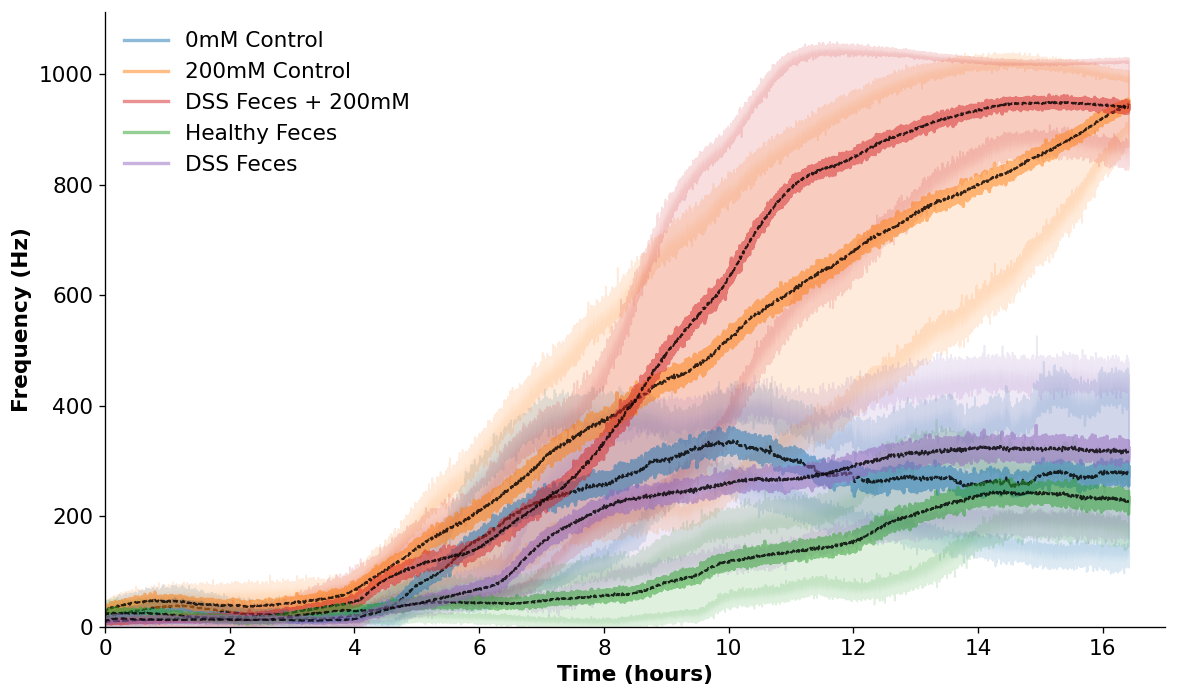

In [4]:

# DATA_DIR = Path(os.getcwd()).resolve().parents[1] / "data" /"processed"/ "SPAD" /"butyrate"
DATA_DIR = Path(os.getcwd())/ "SPAD" /"lactate"
# LACTATE
spad_data = {
     "0mM Control": [
            "lactateForward0mMcontrol_1",
            "lactateForward0mMcontrol_2",
            "lactateForward0mMcontrol_3"
        ],
        "200mM Control": [
            "lactateForward200mMcontrol_1",
            "lactateForward200mMcontrol_2",
            "lactateForward200mMcontrol_3"
        ],
        "DSS Feces + 200mM": [
            "lactateForward200mMDSSFeses_1",
            "lactateForward200mMDSSFeses_2",
            "lactateForward200mMDSSFeses_3"
        ],
        "Healthy Feces": [
            "lactateForward0mMhealthyFeses_1",
            "lactateForward0mMhealthyFeses_2",
            "lactateForward0mMhealthyFeses_3"
        ],
        "DSS Feces": [
            "lactateForward0mMDSSFeses_1",
            "lactateForward0mMDSSFeses_4",
            "lactateForward0mMDSSFeses_2"
        ],
}
#BUTYRATE
# spad_data = {
#         "0mM Control": [
#             "butyrate0mMcontrolMGinverter1",
#             "butyrate0mMcontrolMGinverter2",
#             "butyrate0mMcontrolMGinverter3"
#         ],
#         "50mM Control": [
#             "butyrate100mMcontrolMGinverter1",
#             "butyrate100mMcontrolMGinverter2",
#             "butyrate100mMcontrolMGinverter3"
#         ],
#         "DSS Feces": [
#             "testButyrateDSSsolid1",
#             "testButyrateDSSsolid2",
#             "testButyrateDSSsolid3"
#         ],
#         "Healthy Feces": [
#             "testButyratehealthysolid1",
#             "testButyratehealthysolid2",
#             "testButyratehealthysolid3"
#         ]
#     }

# HEME
 # spad_data = {
    #     "0uM Control": [
    #         "controlHeme0uM1",
    #         "controlHeme0uM3",
    #         "controlHeme0uM4"
    #     ],
    #     "12.5uM Control": [
    #         "controlHeme12_5uM1",
    #         "controlHeme12_5uM2"
    #         # "controlHeme12.5uM3"
    #     ],
    #     "DSS Feces": [
    #         "testHemeDSSsolid4",
    #         # "testHemeDSSsolid2",
    #         "testHemeDSSsolid1"
    #     ],
    #     "Healthy Feces": [
    #         "testHemehealthysolid1",
    #         "testHemehealthysolid2",
    #         "testHemehealthysolid4"
    #     ]
    # }


color_palette = [
            "#1f77b4",  # Blue
            "#ff7f0e",  # Orange
            "#d62728",  # Red
            "#2ca02c",  # Green
            "#9467bd",  # Purple
            "#8c564b",  # Brown
            "#e377c2",  # Pink
            "#7f7f7f",  # Gray
            "#bcbd22",  # Yellow-green
            "#17becf"  # Cyan
        ]
process_and_plot_spad(
    data_dir=DATA_DIR,
    groups_dict=spad_data,
    colors=color_palette,
    max_hours=17,
    show_filtered=True,
    save_prefix="lactate_SPAD"
)